### Import Necessary Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

%matplotlib inline
sns.set_theme(style="darkgrid", palette="Set2")

## Display Money Heist Image

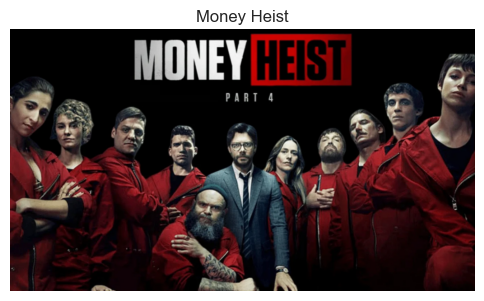

In [8]:
img = Image.open("moneyheist.webp")   
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title("Money Heist")
plt.show()

In [9]:
df = pd.read_csv("money_heist.csv", engine='python', encoding='latin-1')

In [10]:
df.head()

,Season,Episode,Name,On Air,Year,IMDB,Watch Time (minutes),Summary
0,1,1,Efectuar lo acordado,02-May-17,2017,8.4,47,The Professor recruits a young female robber a...
1,1,2,Imprudencias letales,09-May-17,2017,8.4,41,Hostage negotiator Raquel makes initial contac...
2,1,3,Misfire,16-May-17,2017,8.2,50,Police grab an image of the face of one of the...
3,1,4,Caballo de Troya,23-May-17,2017,8.3,51,Raquel is adversely affected by a personal cri...
4,1,5,El día de la marmota,30-May-17,2017,8.4,42,A sudden development in the investigation and ...


In [11]:
print("Columns:\n", df.columns)
print("\nShape:", df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

Columns:
 Index(['Season ', 'Episode ', 'Name', 'On Air', 'Year', 'IMDB',
       'Watch Time (minutes)', 'Summary'],
      dtype='object')

Shape: (36, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Season                36 non-null     int64  
 1   Episode               36 non-null     int64  
 2   Name                  36 non-null     object 
 3   On Air                36 non-null     object 
 4   Year                  36 non-null     int64  
 5   IMDB                  36 non-null     float64
 6   Watch Time (minutes)  36 non-null     int64  
 7   Summary               36 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 2.4+ KB

Describe:
         Season    Episode          Year       IMDB  Watch Time (minutes)
count  36.000000  36.000000    36.000000  36.000000             36.000000
mean 

### Plot Histogram using iloc

<Figure size 600x400 with 0 Axes>

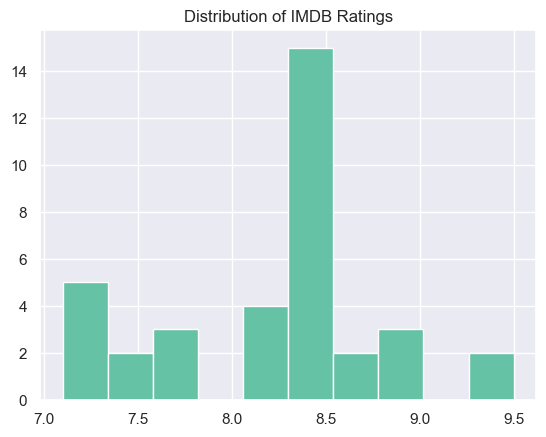

In [34]:
plt.figure(figsize=(6,4))
df.iloc[:,5:6].hist(bins=10)
plt.title("Distribution of IMDB Ratings")
plt.show()

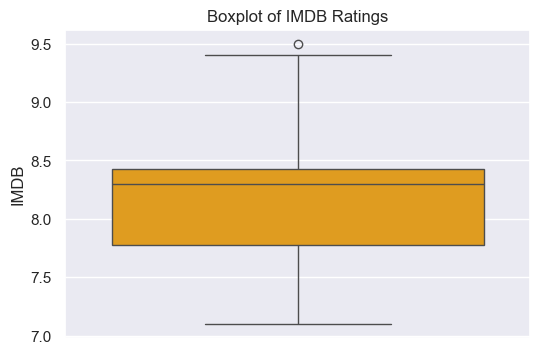

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['IMDB'], color='orange')
plt.title("Boxplot of IMDB Ratings")
plt.show()

In [16]:
high_rated = df[df['IMDB'] > 8.5][['Season ','Episode ','Name','IMDB']]
print(high_rated.head(3))

    Season   Episode                          Name  IMDB
8         1         9  El que la sigue la consigue   8.7
9         2         1     Se acabaron las máscaras   8.6
11        2         3         Cuestión de eficacia   8.8


In [18]:
seasons = df['Season '].unique().tolist()
print("Seasons:", seasons)

Seasons: [1, 2, 3, 4, 5]


In [19]:
episodes_per_season = df.groupby('Season ')['Episode '].count().reset_index()
episodes_per_season.columns = ['Season ', 'No_of_Episodes']
print(episodes_per_season)

   Season   No_of_Episodes
0        1               9
1        2               6
2        3               8
3        4               8
4        5               5


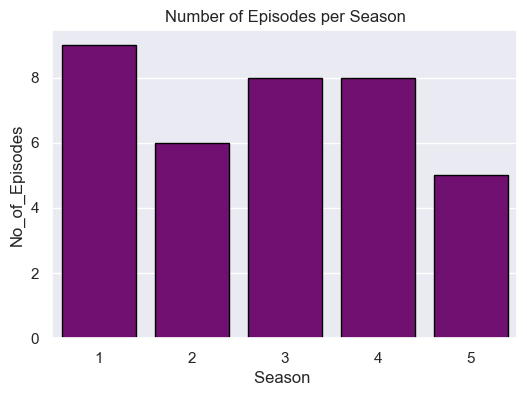

Season with Highest Episodes:
   Season   No_of_Episodes
0        1               9


In [38]:
plt.figure(figsize=(6,4))
sns.barplot(x='Season ', y='No_of_Episodes', data=episodes_per_season,color='purple', edgecolor='black')
plt.title("Number of Episodes per Season")
plt.show()

print("Season with Highest Episodes:")
print(episodes_per_season.sort_values(by='No_of_Episodes', ascending=False).head(1))

C:\Users\hp331\AppData\Local\Temp\ipykernel_16692\769094517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=df, palette= 'pastel')


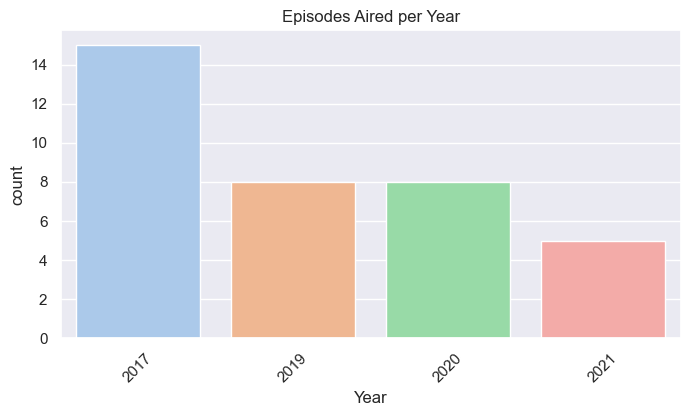

In [41]:
plt.figure(figsize=(8,4))
sns.countplot(x='Year', data=df, palette= 'pastel')
plt.title("Episodes Aired per Year")
plt.xticks(rotation=45)
plt.show()

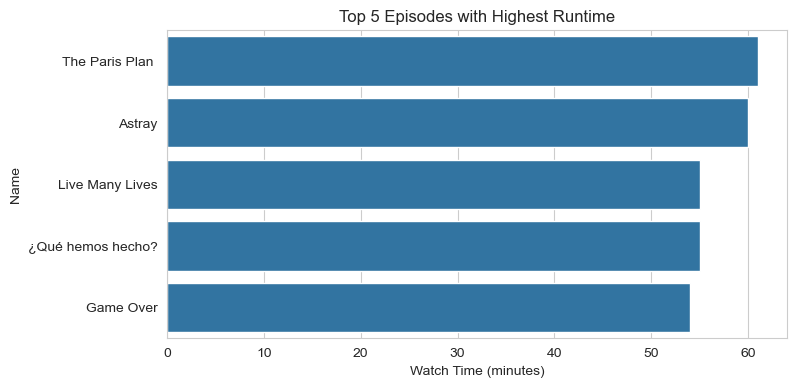

In [23]:
top_runtime = df.sort_values(by='Watch Time (minutes)', ascending=False).head(5)

plt.figure(figsize=(8,4))
sns.barplot(x='Watch Time (minutes)', y='Name', data=top_runtime)
plt.title("Top 5 Episodes with Highest Runtime")
plt.show()

C:\Users\hp331\AppData\Local\Temp\ipykernel_16692\2382806639.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IMDB', y='Name', data=top_imdb, palette='viridis')


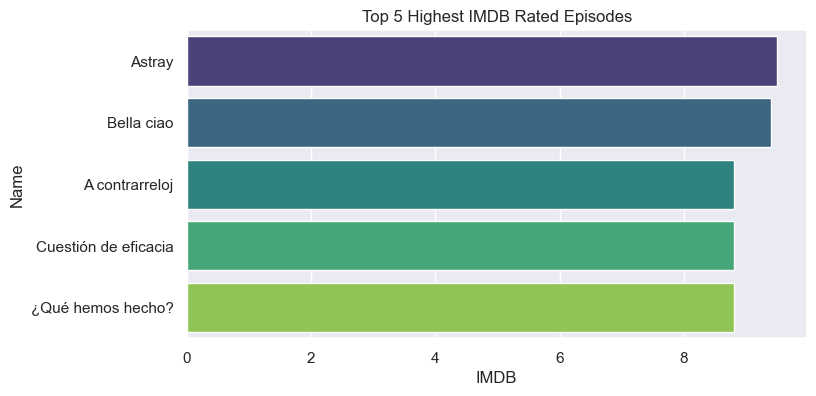

In [42]:
top_imdb = df.sort_values(by='IMDB', ascending=False).head(5)

plt.figure(figsize=(8,4))
sns.barplot(x='IMDB', y='Name', data=top_imdb, palette='viridis')
plt.title("Top 5 Highest IMDB Rated Episodes")
plt.show()

In [25]:
total_watchtime = df.groupby('Year')['Watch Time (minutes)'].sum().reset_index()
print(total_watchtime)

   Year  Watch Time (minutes)
0  2017                   685
1  2019                   391
2  2020                   402
3  2021                   258


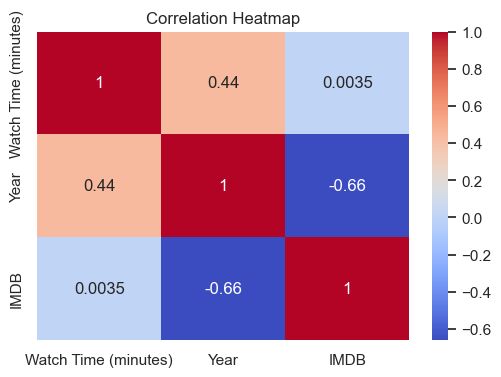

In [45]:
plt.figure(figsize=(6,4))
corr = df[['Watch Time (minutes)','Year','IMDB']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

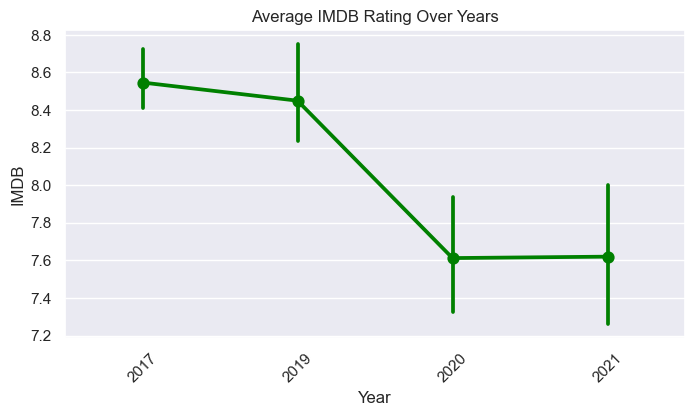

In [47]:
plt.figure(figsize=(8,4))
sns.pointplot(x='Year', y='IMDB', data=df, color='green')
plt.title("Average IMDB Rating Over Years")
plt.xticks(rotation=45)
plt.show()

   Season   Watch Time (minutes)
0        1                   406
3        4                   402
2        3                   391
1        2                   279
4        5                   258


C:\Users\hp331\AppData\Local\Temp\ipykernel_16692\3120156628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season ', y='Watch Time (minutes)', data=season_watchtime, palette='Set1')


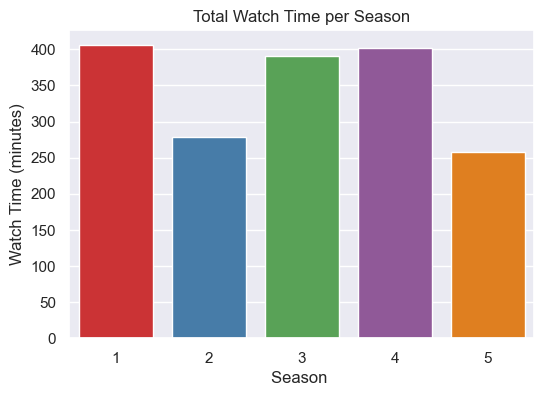

Season that took longest time:
   Season   Watch Time (minutes)
0        1                   406


In [49]:
season_watchtime = df.groupby('Season ')['Watch Time (minutes)'].sum().reset_index()

print(season_watchtime.sort_values(by='Watch Time (minutes)', ascending=False))

plt.figure(figsize=(6,4))
sns.barplot(x='Season ', y='Watch Time (minutes)', data=season_watchtime, palette='Set1')
plt.title("Total Watch Time per Season")
plt.show()

print("Season that took longest time:")
print(season_watchtime.sort_values(by='Watch Time (minutes)', ascending=False).head(1))